# Structural Shift: GNN vs SpectralGNN Alignment

This notebook compares `gnn` (weight alignment) and `spectral_gnn` (filter alignment) runs.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path('/home/bini/codes/GDA/KDD/SCGDA/../../__saved__/struct_shift')
RUN_DIR = sorted(BASE_DIR.glob('run_*'))[-1]
MODELS = ('gnn', 'spectral_gnn')
LEGACY_FILE_PREFIX = {'gnn': 'weight_align', 'spectral_gnn': 'filter_align'}
COLORS = {'gnn': '#1f77b4', 'spectral_gnn': '#d62728'}


def _pick_prefix(run_dir: Path, model_name: str) -> str:
    """Return a valid file prefix for model artifacts."""
    direct = run_dir / f'{model_name}_history.npz'
    if direct.exists():
        return model_name
    legacy = LEGACY_FILE_PREFIX[model_name]
    fallback = run_dir / f'{legacy}_history.npz'
    if fallback.exists():
        return legacy
    raise FileNotFoundError(f'No history file for {model_name} in {run_dir}')


def load_results(run_dir: Path, models: tuple[str, ...]) -> dict[str, dict[str, np.lib.npyio.NpzFile]]:
    """Load history and embedding files for requested models."""
    out: dict[str, dict[str, np.lib.npyio.NpzFile]] = {}
    for model_name in models:
        prefix = _pick_prefix(run_dir, model_name)
        out[model_name] = {
            'prefix': prefix,
            'history': np.load(run_dir / f'{prefix}_history.npz'),
            'embeddings': np.load(run_dir / f'{prefix}_embeddings.npz'),
        }
    return out


results = load_results(RUN_DIR, MODELS)
print('run:', RUN_DIR)
for m in MODELS:
    print(f'{m} <- {results[m]["prefix"]}')

run: /home/bini/codes/GDA/KDD/SCGDA/../../__saved__/struct_shift/run_0217_233148
gnn <- gnn
spectral_gnn <- spectral_gnn


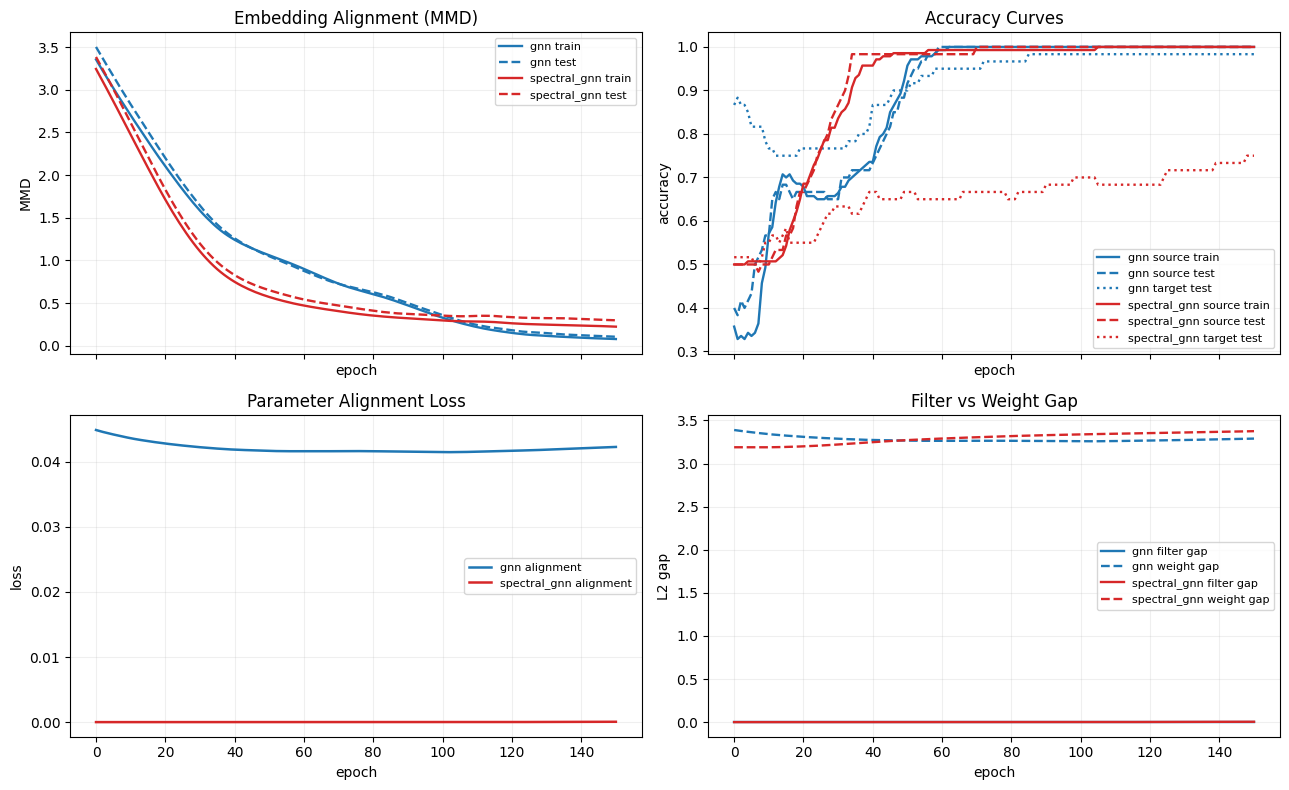

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

for model_name in MODELS:
    h = results[model_name]['history']
    e = h['epoch']
    c = COLORS[model_name]

    axes[0, 0].plot(e, h['mmd_train'], color=c, lw=1.7, ls='-', label=f'{model_name} train')
    axes[0, 0].plot(e, h['mmd_test'], color=c, lw=1.7, ls='--', label=f'{model_name} test')

    axes[0, 1].plot(e, h['source_train_acc'], color=c, lw=1.7, ls='-', label=f'{model_name} source train')
    axes[0, 1].plot(e, h['source_test_acc'], color=c, lw=1.7, ls='--', label=f'{model_name} source test')
    axes[0, 1].plot(e, h['target_test_acc'], color=c, lw=1.7, ls=':', label=f'{model_name} target test')

    axes[1, 0].plot(e, h['alignment_loss'], color=c, lw=1.8, label=f'{model_name} alignment')
    axes[1, 1].plot(e, h['filter_gap'], color=c, lw=1.7, ls='-', label=f'{model_name} filter gap')
    axes[1, 1].plot(e, h['weight_gap'], color=c, lw=1.7, ls='--', label=f'{model_name} weight gap')

axes[0, 0].set_title('Embedding Alignment (MMD)')
axes[0, 1].set_title('Accuracy Curves')
axes[1, 0].set_title('Parameter Alignment Loss')
axes[1, 1].set_title('Filter vs Weight Gap')

for ax in axes.ravel():
    ax.set_xlabel('epoch')
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)

axes[0, 0].set_ylabel('MMD')
axes[0, 1].set_ylabel('accuracy')
axes[1, 0].set_ylabel('loss')
axes[1, 1].set_ylabel('L2 gap')

fig.tight_layout()
plt.show()

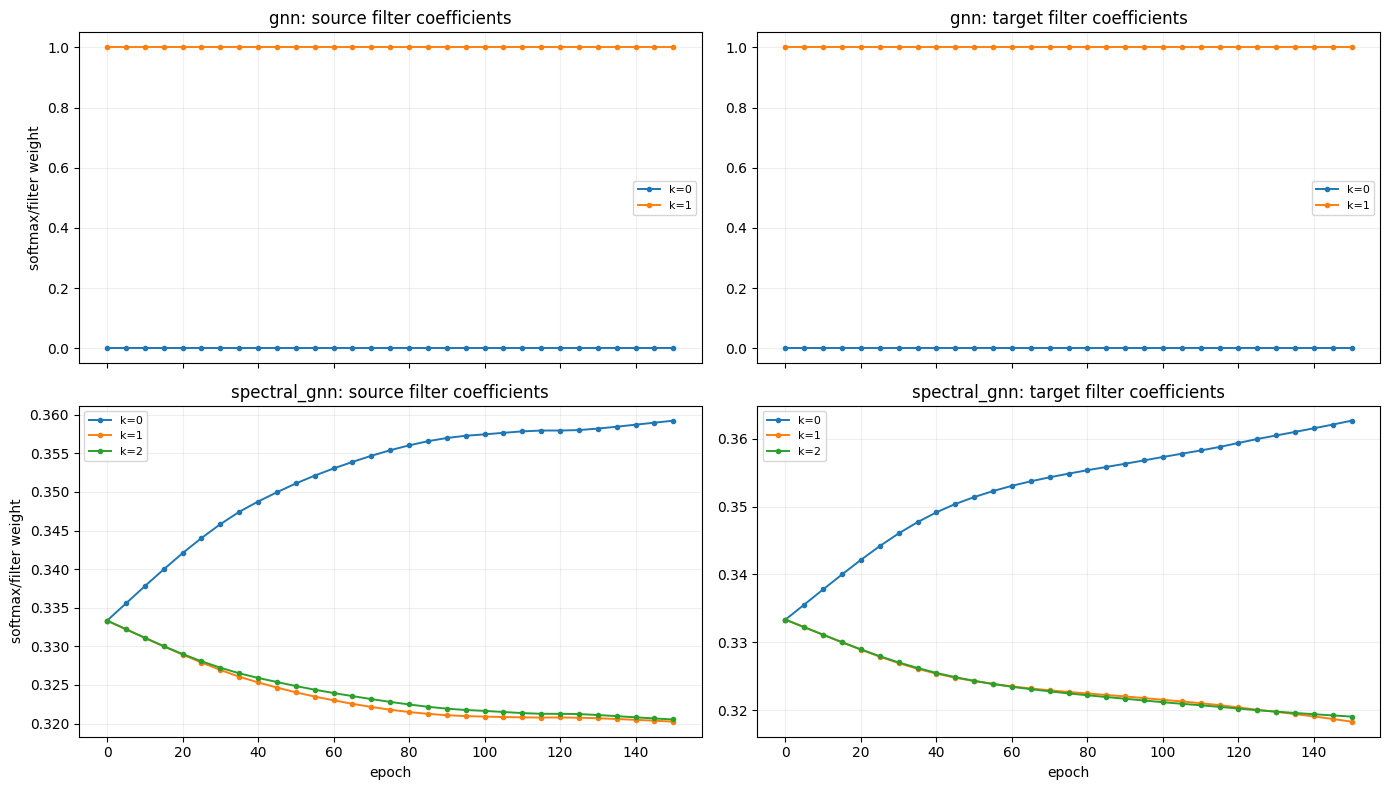

In [3]:
def plot_filter_progression(results: dict[str, dict[str, np.lib.npyio.NpzFile]], models: tuple[str, ...]) -> None:
    """Plot source and target filter coefficients for each model."""
    fig, axes = plt.subplots(len(models), 2, figsize=(14, 4 * len(models)), sharex=True)
    axes = np.atleast_2d(axes)

    for row, model_name in enumerate(models):
        emb = results[model_name]['embeddings']
        epochs = emb['epochs']
        src = emb['source_filter_weights']
        tgt = emb['target_filter_weights']

        for k in range(src.shape[1]):
            axes[row, 0].plot(epochs, src[:, k], marker='o', ms=3, lw=1.4, label=f'k={k}')
            axes[row, 1].plot(epochs, tgt[:, k], marker='o', ms=3, lw=1.4, label=f'k={k}')

        axes[row, 0].set_title(f'{model_name}: source filter coefficients')
        axes[row, 1].set_title(f'{model_name}: target filter coefficients')
        axes[row, 0].set_ylabel('softmax/filter weight')
        axes[row, 0].grid(alpha=0.2)
        axes[row, 1].grid(alpha=0.2)
        axes[row, 0].legend(fontsize=8)
        axes[row, 1].legend(fontsize=8)

    axes[-1, 0].set_xlabel('epoch')
    axes[-1, 1].set_xlabel('epoch')
    fig.tight_layout()
    plt.show()


plot_filter_progression(results, MODELS)

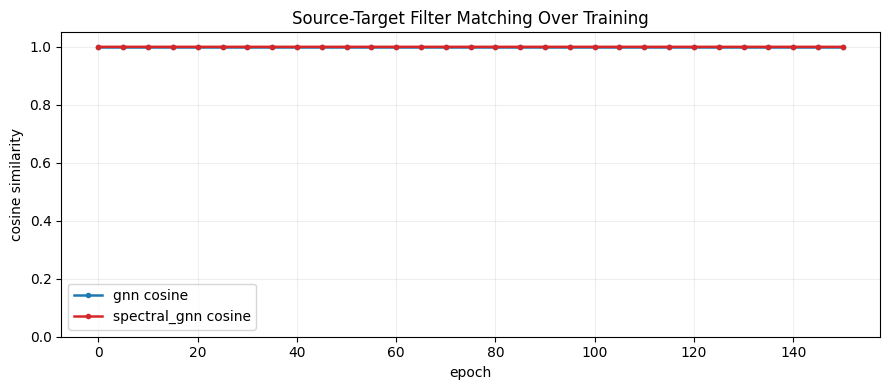

In [4]:
def cosine_match(a: np.ndarray, b: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """Return cosine similarity between row-wise vectors."""
    num = (a * b).sum(axis=1)
    den = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1) + eps
    return num / den


plt.figure(figsize=(9, 4))
for model_name in MODELS:
    emb = results[model_name]['embeddings']
    epochs = emb['epochs']
    sim = cosine_match(emb['source_filter_weights'], emb['target_filter_weights'])
    plt.plot(epochs, sim, marker='o', ms=3, lw=1.8, color=COLORS[model_name], label=f'{model_name} cosine')

plt.title('Source-Target Filter Matching Over Training')
plt.xlabel('epoch')
plt.ylabel('cosine similarity')
plt.ylim(0.0, 1.05)
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()